# 📚 Week 07 - Day 04: Natural Language Processing (NLP) using Artificial Neural Networks (ANN)

Welcome to today's session! Today we will learn how to teach a Neural Network to understand text. We will build a **Sentiment Analysis** model to predict product ratings based on customer reviews.

### 🎯 Learning Objectives:
1. Understand **Tokenization** (converting text to numbers).
2. Understand **Padding** (making all texts the same length).
3. Learn about **Word Embeddings** (giving meaning to numbers).
4. Build and train an **ANN** for text regression.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 1️⃣ Step 1: Loading the Dataset
We will start with a mock dataset of 1,000 product reviews to understand the basics. Our goal is to predict the `Rating` (1 to 5) from the `ReviewText`.


In [2]:
df = pd.read_csv(r"D:\NAVTTC-AI-Course\datasets\product_reviews_mock_data.csv")
df.head()

,ReviewID,ProductID,UserID,Rating,ReviewText,ReviewDate
0,REV2000,Product_E,User_114,4,fantastic. wonderful experience.,2023-04-17
1,REV2001,Product_C,User_186,2,broke easily. awful.,2023-11-27
2,REV2002,Product_E,User_101,3,met expectations. five stars.,2023-12-10
3,REV2003,Product_A,User_175,5,very satisfied. wonderful experience.,2023-11-10
4,REV2004,Product_C,User_158,1,worst purchase. one star.,2024-05-25


In [3]:
# Let's extract our input features (X) and target labels (y)
X = df["ReviewText"].values
y = df["Rating"].values

print(f"First review: '{X[0]}'")
print(f"Rating: {y[0]}/5")

First review: 'fantastic. wonderful experience.'
Rating: 4/5


## 2️⃣ Step 2: Tokenization (Words to Numbers)
Machine Learning models can't read text directly; they only understand numbers. 
**Tokenization** is the process of mapping every unique word to a specific integer index.


In [4]:
# Initialize the Tokenizer
# <OOV> stands for 'Out Of Vocabulary'. It's used for words the model hasn't seen during training.
tokenizer = Tokenizer(oov_token="<OOV>")

# Fit the tokenizer on our text data (builds the word index dictionary)
tokenizer.fit_on_texts(X)

# Let's see the total number of unique words learned
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for the 0 padding token we will use later
print(f"Total unique words in vocabulary: {vocab_size}")

Total unique words in vocabulary: 74


In [6]:
tokenizer.word_index

{'<OOV>': 1,
 'bad': 2,
 'product': 3,
 'experience': 4,
 'recommend': 5,
 'works': 6,
 'purchase': 7,
 'to': 8,
 'use': 9,
 'features': 10,
 'quality': 11,
 'not': 12,
 'very': 13,
 'expectations': 14,
 'perfectly': 15,
 'fantastic': 16,
 'wonderful': 17,
 'five': 18,
 'stars': 19,
 'highly': 20,
 'worst': 21,
 'waste': 22,
 'of': 23,
 'money': 24,
 'love': 25,
 'this': 26,
 'easy': 27,
 'difficult': 28,
 'one': 29,
 'star': 30,
 'best': 31,
 'ever': 32,
 'excellent': 33,
 'missing': 34,
 'would': 35,
 'broke': 36,
 'easily': 37,
 'customer': 38,
 'service': 39,
 'was': 40,
 'disappointed': 41,
 'awful': 42,
 'great': 43,
 'value': 44,
 'terrible': 45,
 'amazing': 46,
 'poor': 47,
 'does': 48,
 'work': 49,
 'some': 50,
 'pros': 51,
 'and': 52,
 'cons': 53,
 'as': 54,
 'expected': 55,
 'exceeded': 56,
 'satisfied': 57,
 "it's": 58,
 'okay': 59,
 'met': 60,
 'neither': 61,
 'good': 62,
 'nor': 63,
 'average': 64,
 'nothing': 65,
 'special': 66,
 'decent': 67,
 'for': 68,
 'the': 69,
 'p

In [9]:
# Convert our text sentences into sequences of numbers
sequences = tokenizer.texts_to_sequences(X)

print("Original Text:", X[999])
print("Tokenized Sequence:", sequences[999])

Original Text: waste of money. worst purchase. works as expected.
Tokenized Sequence: [22, 23, 24, 21, 7, 6, 54, 55]


## 3️⃣ Step 3: Padding (Uniform Sequence Lengths)
Neural networks require standard shapes. Since sentences have different lengths, we **pad** them (add zeroes at the end) or truncate them so they are all the exact same size.


In [10]:
# We set a maximum length for a review (e.g., 15 words) and pad the rest with 0s at the end ('post')
max_length = 15

padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

print("Padded Sequence Shape:", padded_sequences.shape)
print("Padded Sequence:\n", padded_sequences[0])

Padded Sequence Shape: (1000, 15)
Padded Sequence:
 [16 17  4  0  0  0  0  0  0  0  0  0  0  0  0]


## 4️⃣ Step 4: Train / Test Split
We split our data to evaluate how well our model performs on unseen data.


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (800, 15)
Testing data size: (200, 15)


## 5️⃣ Step 5: Building the ANN Model with Embeddings
Instead of treating token IDs like continuous numbers (which is mathematically incorrect because '5' isn't larger than '4' in meaning), we use an **Embedding Layer**.
This layer maps each word ID to a dense vector of floating-point values, allowing the network to mathematically learn similarities between words!


In [16]:
a = (15,)
a

(15,)

In [22]:
embedding_dim = 16

model = models.Sequential([
    # 1. Embedding Layer: Converts token indices into dense word vectors
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

    # layers.Input((15,)),
    
    # 2. Flatten: Flattens the 2D embedding into 1D so the Dense layer can process it
    layers.Flatten(),
    
    # 3. Hidden Layers: Standard ANN fully connected layers to learn patterns
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    
    # 4. Output Layer: A single neuron for Regression (predicting continuous 1-5 rating)
    layers.Dense(1)
])

# Compile the model for regression using Mean Squared Error (MSE)
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 6️⃣ Step 6: Training and Evaluation
Let's teach the model!


In [23]:
print("Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Training the model...
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 7.7452 - mae: 2.3885 - val_loss: 1.9706 - val_mae: 1.1864
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.0521 - mae: 1.1995 - val_loss: 1.7584 - val_mae: 1.1108
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3559 - mae: 0.9617 - val_loss: 1.0013 - val_mae: 0.7984
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5987 - mae: 0.6117 - val_loss: 0.4066 - val_mae: 0.5265
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3049 - mae: 0.4756 - val_loss: 0.3144 - val_mae: 0.4951
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2526 - mae: 0.4479 - val_loss: 0.2847 - val_mae: 0.4779
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2356 - mae: 0.4405 - val_loss: 0.2700 - val_mae: 0.4734
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2246 - mae: 0.4311 - val_loss: 0.2651 - val_mae: 0.4720
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1

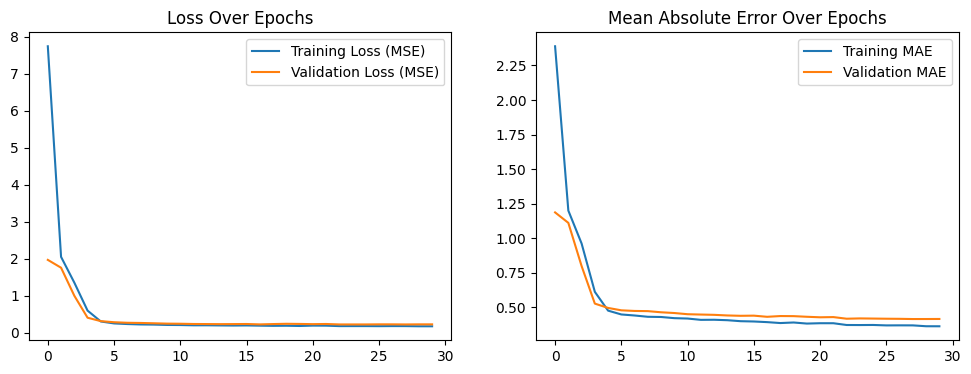

In [24]:
# Plotting the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Mean Absolute Error Over Epochs')
plt.legend()

plt.show()

In [25]:
X_test[:5]

array([[47, 11, 13, 41,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [13, 57, 20,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [27,  8,  9, 20,  5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [28,  8,  9,  2,  4,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [16, 13, 57, 65, 66,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]],
      dtype=int32)

In [29]:
# Testing the model on a few validation samples
predictions = model.predict(X_test[:5])

print("\n--- Sample Predictions ---")
for i in range(5):
    print(f"Real Rating: {y_test[i]} | Predicted: {int(predictions[i][0])}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

--- Sample Predictions ---
Real Rating: 1 | Predicted: 1
Real Rating: 4 | Predicted: 4
Real Rating: 5 | Predicted: 4
Real Rating: 1 | Predicted: 1
Real Rating: 5 | Predicted: 4


## 7️⃣ Bonus Challenge: Try It On Yourself! 
Let's see if the ANN has learned something useful. We will write our own reviews and pass them through our pipeline!


In [31]:
def predict_review(text):
    # 1. Tokenize the text
    seq = tokenizer.texts_to_sequences([text])
    # 2. Pad the sequence
    pad_seq = pad_sequences(seq, maxlen=max_length, padding="post", truncating="post")
    # 3. Predict
    pred = model.predict(pad_seq, verbose=0)
    print(f"Review: '{text}' --> Predicted Rating: {pred[0][0]:.2f} / 5.0")

predict_review("This product is absolutely amazing and I love it!")
predict_review("Terrible experience, completely broke on day one.")
predict_review("It's okay, nothing special but gets the job done.")
predict_review("This is a cat")

Review: 'This product is absolutely amazing and I love it!' --> Predicted Rating: 2.93 / 5.0
Review: 'Terrible experience, completely broke on day one.' --> Predicted Rating: 1.75 / 5.0
Review: 'It's okay, nothing special but gets the job done.' --> Predicted Rating: 2.80 / 5.0
Review: 'This is a cat' --> Predicted Rating: 3.33 / 5.0


## 🌍 Extending to Real-World Datasets
Now that you know the pipeline (Tokenization $\rightarrow$ Padding $\rightarrow$ Embedding $\rightarrow$ Dense), you can apply this logic to massive datasets.
Below is the code to download a real Twitter Sentiment Analysis dataset from Kaggle to use for practice!


In [ ]:
import kagglehub

print("Downloading Kaggle Dataset...")
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Path to dataset files:", path)

In [ ]:
import shutil
shutil.move(path, './')

In [33]:
# Load and explore the new dataset
train_df = pd.read_csv(r'D:\NAVTTC-AI-Course\datasets\Sentiment Analysis Dataset\train.csv', encoding='latin1')
print(f"Real world dataset loaded! Size: {train_df.shape}")

train_df[['text', 'sentiment']].head()

Real world dataset loaded! Size: (27481, 10)


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [62]:
train_df.dropna(inplace=True)

In [91]:
X = train_df['text']
y = train_df['sentiment']

print('Shape of Input: ',X.shape)
print('Shape of Output: ',y.shape)

Shape of Input:  (27480,)
Shape of Output:  (27480,)


In [64]:

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X)

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1  # +1 for the 0 padding token we will use later
print(f"Total unique words in vocabulary: {vocab_size}")


Total unique words in vocabulary: 26600


In [66]:
# Convert our text sentences into sequences of numbers
sequences = tokenizer.texts_to_sequences(X)

print("Original Text:", X[0])
print("Tokenized Sequence:", sequences[0])

Original Text:  I`d have responded, if I were going
Tokenized Sequence: [2, 166, 20, 10457, 74, 2, 151, 49]


In [67]:
max_length = 30

padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

print("Padded Sequence Shape:", padded_sequences.shape)
print("Padded Sequence:\n", padded_sequences[0])

Padded Sequence Shape: (27480, 30)
Padded Sequence:
 [    2   166    20 10457    74     2   151    49     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]


In [92]:
y = y.map({'neutral': 0, 'positive': 1, 'negative': 2})

y[:5]

0    0
1    2
2    2
3    2
4    2
Name: sentiment, dtype: int64

In [95]:
y_label = y.values
y_label[:5]

array([0, 2, 2, 2, 2])

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y_label, 
                    test_size = 0.2, 
                    random_state = 100)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21984, 30), (5496, 30), (21984,), (5496,))

In [110]:
embedding_dim = 32

model = models.Sequential([
    # 1. Embedding Layer: Converts token indices into dense word vectors
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

    # layers.Input((15,)),
    
    # 2. Flatten: Flattens the 2D embedding into 1D so the Dense layer can process it
    layers.Flatten(),
    
    # 3. Hidden Layers: Standard ANN fully connected layers to learn patterns
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    
    # 4. Output Layer: A single neuron for Regression (predicting continuous 1-5 rating)
    layers.Dense(3)
])

# Compile the model for regression using Mean Squared Error (MSE)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [111]:
print("Training the model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Training the model...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3980 - loss: 1.0999 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4038 - loss: 1.0986 - val_accuracy: 0.4074 - val_loss: 1.0986
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4038 - loss: 